# Mobile Segment Anything Model (SAM)

----

Conda env : [cv_playgrounds](../README.md#setup-a-conda-environment)

----

- Ref: 
    - https://docs.ultralytics.com/models/mobile-sam/#how-was-mobilesam-trained-and-is-the-training-code-available

In [5]:
!nvidia-smi

Fri Nov 21 21:16:44 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2080 Ti     On  |   00000000:01:00.0  On |                  N/A |
| 32%   48C    P5             36W /  250W |    8712MiB /  11264MiB |     27%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Download test data

In [4]:
from ultralytics.utils.downloads import safe_download
images = ["bus.jpg", "zidane.jpg"]
for img in images:
  path = safe_download(f"https://ultralytics.com/assets/{img}", dir="temp_assets")

### Mobile-SAM :: Point prompt


image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/zidane.jpg: 1024x1024 1 0, 39.0ms
Speed: 3.4ms preprocess, 39.0ms inference, 0.8ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/zidane.jpg: 1024x1024 1 0, 1 1, 38.1ms
Speed: 3.9ms preprocess, 38.1ms inference, 0.8ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/zidane.jpg: 1024x1024 1 0, 37.2ms
Speed: 3.4ms preprocess, 37.2ms inference, 0.8ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/zidane.jpg: 1024x1024 1 0, 38.2ms
Speed: 4.5ms preprocess, 38.2ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)


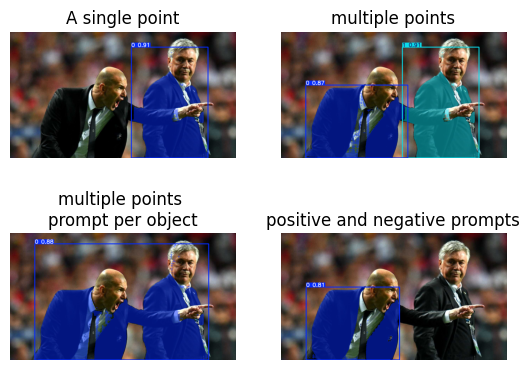

In [6]:
from ultralytics import SAM
import matplotlib.pyplot as plt
import cv2

fig, axs = plt.subplots(2, 2)
# Load the model
model = SAM("./temp_model/mobile_sam.pt")

# Predict a segment based on a single point prompt
results = model.predict("./temp_assets/zidane.jpg", points=[900, 370], labels=[1])
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
axs[0, 0].imshow(rgb_image)
axs[0, 0].set_axis_off()
axs[0, 0].set_title("A single point")

# Predict multiple segments based on multiple points prompt
results = model.predict("./temp_assets/zidane.jpg", points=[[400, 370], [900, 370]], labels=[1, 1])
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
axs[0, 1].imshow(rgb_image)
axs[0, 1].set_axis_off()
axs[0, 1].set_title("multiple points")


# Predict a segment based on multiple points prompt per object
results = model.predict("./temp_assets/zidane.jpg", points=[[[400, 370], [900, 370]]], labels=[[1, 1]])
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
axs[1, 0].imshow(rgb_image)
axs[1, 0].set_axis_off()
axs[1, 0].set_title("multiple points \nprompt per object")


# Predict a segment using both positive and negative prompts.
results = model.predict("./temp_assets/zidane.jpg", points=[[[400, 370], [900, 370]]], labels=[[1, 0]])
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
axs[1, 1].imshow(rgb_image)
axs[1, 1].set_axis_off()
axs[1, 1].set_title("positive and negative prompts")

plt.show()

### Mobile-SAM :: Box prompt


image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/zidane.jpg: 1024x1024 1 0, 40.2ms
Speed: 3.6ms preprocess, 40.2ms inference, 0.7ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/zidane.jpg: 1024x1024 1 0, 1 1, 37.6ms
Speed: 3.4ms preprocess, 37.6ms inference, 0.6ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/zidane.jpg: 1024x1024 1 0, 36.1ms
Speed: 3.9ms preprocess, 36.1ms inference, 0.7ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/zidane.jpg: 1024x1024 1 0, 36.3ms
Speed: 3.3ms preprocess, 36.3ms inference, 1.1ms postprocess per image at shape (1, 3, 1024, 1024)


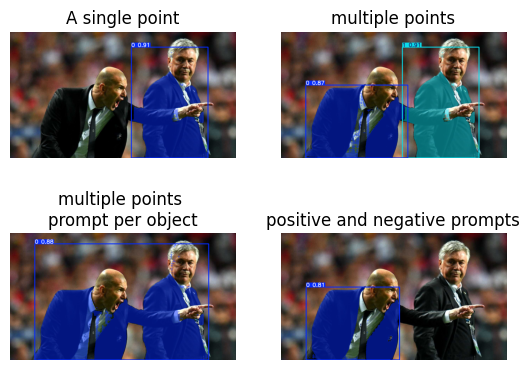

In [8]:
from ultralytics import SAM
import matplotlib.pyplot as plt
import cv2

fig, axs = plt.subplots(2, 2)
# Load the model
model = SAM("./temp_model/mobile_sam.pt")

# Predict a segment based on a single point prompt
results = model.predict("./temp_assets/zidane.jpg", points=[900, 370], labels=[1])
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
axs[0, 0].imshow(rgb_image)
axs[0, 0].set_axis_off()
axs[0, 0].set_title("A single point")

# Predict multiple segments based on multiple points prompt
results = model.predict("./temp_assets/zidane.jpg", points=[[400, 370], [900, 370]], labels=[1, 1])
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
axs[0, 1].imshow(rgb_image)
axs[0, 1].set_axis_off()
axs[0, 1].set_title("multiple points")


# Predict a segment based on multiple points prompt per object
results = model.predict("./temp_assets/zidane.jpg", points=[[[400, 370], [900, 370]]], labels=[[1, 1]])
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
axs[1, 0].imshow(rgb_image)
axs[1, 0].set_axis_off()
axs[1, 0].set_title("multiple points \nprompt per object")


# Predict a segment using both positive and negative prompts.
results = model.predict("./temp_assets/zidane.jpg", points=[[[400, 370], [900, 370]]], labels=[[1, 0]])
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
axs[1, 1].imshow(rgb_image)
axs[1, 1].set_axis_off()
axs[1, 1].set_title("positive and negative prompts")

plt.show()